In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../../")

os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split, KFold

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian, decimate

%matplotlib inline

In [2]:
data_dir = '../../../data/recordings/nk341_mPFC/' 
out_dir = "../../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_669, 7_869
bin_size = 0.05
bs = 512 # batch size 

z_score = False
deconvolve = False 
convolve_spikes = True
neuromodulation = 'postsynaptic'
normalize_neuromod = True 
sim_s = False 
center = False

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'electrophysiology')
    files = [f for f in os.listdir(spikes_dir) if os.path.isfile(os.path.join(spikes_dir, f))]
    files = sorted(files)
    t_start, t_end = 10, 0
    for f in files:
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))
    
    # remove twenty seconds in the end  
    t_end = t_end - 20
    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)

    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    if deconvolve:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved_2.csv', header=None).to_numpy().flatten()
    else:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_full.csv', header=None).to_numpy().flatten()
    # downsample
    fs, target_fs = 1000, 1 / bin_size
    downsample_factor = int(fs / target_fs)
    downsampled_signal = decimate(lc_neuromod, downsample_factor, ftype='fir', zero_phase=True)
    print(f'length of downsampled signal: {len(downsampled_signal)}')
    print(f'length of original signal: {len(lc_neuromod)}') 
    lc_neuromod = downsampled_signal 
    
    # select in window 
    lc_neuromod = lc_neuromod[int(t_start/bin_size):int(t_end/bin_size)]
    # replace nans with zero 
    lc_neuromod = np.nan_to_num(lc_neuromod)
    # z-score 
    if z_score:
        neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    else:
        neuromod_activity = lc_neuromod
    # center 
    if center:
        neuromod_activity += np.abs(neuromod_activity.min())
    # z-score the neurons
    spike_counts = (spike_counts - spike_counts.mean(axis=1, keepdims=True)) / spike_counts.std(axis=1, keepdims=True)
    if convolve_spikes:
        kernel_size = 25
        sigma = 5
        
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
    # load trials info 
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

In [4]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

t_end = 7869
length of downsampled signal: 157771
length of original signal: 7888521


/tmp/ipykernel_89374/2601950557.py:52: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated since SciPy 1.1.0 and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)


In [ ]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# convert x-axis from ms to s 
# ticks = plt.xticks()[0][1:-1]
# plt.xticks(ticks, labels=[f'{tick / 1000.0}' for tick in ticks]) 

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

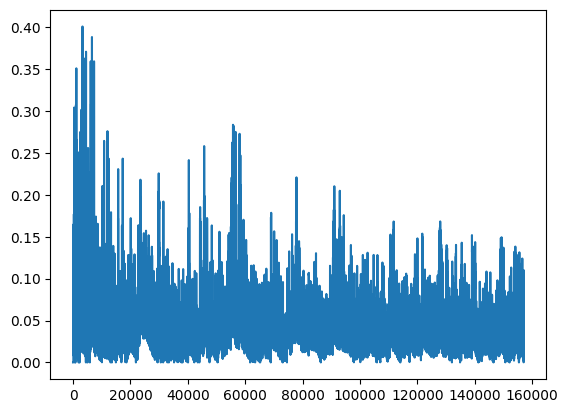

In [23]:
plt.plot(neuromod_activity)

### Create baseline training and test data 

In [5]:
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

### Add post-trial baseline activity to train and test samples 

In [6]:
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)

s_pt_baseline = (s_pt_baseline - s_pt_baseline.min()) / (s_pt_baseline.max() - s_pt_baseline.min())

In [ ]:
rank, N = 4, spike_counts.shape[0]

seq_periods_eval = [[]]
test_samples = spike_counts_pt_baseline
s_test = s_pt_baseline

seq_periods = [[0, len(spike_counts_pt_baseline)]]

task_params = {
    "dur": 100,
    "n_trials": 3000,
    "name": "",
    "dataset_name": data_dir,
}

task = DTTDataset(task_params, 
                    spike_counts_pt_baseline.T, 
                    s_train=s_pt_baseline, 
                    s_test=s_test,
                    seq_periods=seq_periods,
                    seq_periods_eval=seq_periods_eval,
                    data_eval=test_samples.T)

enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
rnn_params = {
    "clipped": True,
    "train_noise_x": True,  # False
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.1,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.9,
    "readout_rates": "currents",
    "train_obs_bias": False,
    "train_obs_weights": False, #True
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",# "softplus",
    "neuromodulation": neuromodulation, 
    "train_nm_params": True
}
# initialise training parameters
training_params = {
    "smooth_at_eval": 200,
    "run_eval": False,
    "t_forward": 0,
    "lr": 1e-3,
    "step_size": 1, 
    "gamma": 0.998849,
    "lr_end": 1e-6,
    "n_epochs": 1000,
    "grad_norm": False,
    "eval_epochs": 10,
    "batch_size": bs,
    "cuda": True,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "opt_eps": 1e-8,
    "grad_norm": 0,
    "sim_obs_noise": 0,
    "k": 64,
    "sim_v": False,
    "sim_s": sim_s,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "observation_likelihood": "Gauss",  # observation likelihood,
    "neuromodulation": neuromodulation 
}

dim_x = task.data.shape[1]
dim_z = rank
dim_N = N
dim_s = 1 

VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_N": dim_N,
    "dim_s": dim_s,
    "enc_architecture": "Inv_Obs", #CNN
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "rnn_params": rnn_params,
    "causal": False
}
vae = VAE(VAE_params)
train_VAE(vae, 
    training_params, 
    task, 
    sync_wandb=True, 
    out_dir=out_dir, 
    fname=f"dtt_{neuromodulation}_rank_{dim_z}")

Neuromodulation type: postsynaptic
using clipped ReLU activation
using uniform init
weight scaler 1
Training on : cuda
Learning rate decay factor 0.9931160484209338
epoch 1 loss: 2589.4750, ll: -2589.4750, ll_x: 2584.6246, ll_z: -5.2447 H: 10.1277, alpha: 0.24, lr: 0.001000, N_z: 0.0999, N_x: 0.1040
epoch 2 loss: 1989.3159, ll: -1989.3159, ll_x: 1984.5094, ll_z: -5.2312 H: 10.0699, alpha: 0.24, lr: 0.000999, N_z: 0.0999, N_x: 0.1041
epoch 3 loss: 1980.5836, ll: -1980.5836, ll_x: 1975.7895, ll_z: -5.2416 H: 10.0688, alpha: 0.24, lr: 0.000998, N_z: 0.0999, N_x: 0.1041
epoch 4 loss: 1972.1197, ll: -1972.1197, ll_x: 1967.3407, ll_z: -5.2540 H: 10.0672, alpha: 0.24, lr: 0.000997, N_z: 0.0999, N_x: 0.1041


In [8]:
save_model(vae, training_params, task_params, f'dtt_{neuromodulation}_rank_{dim_z}_{dim_N}_gauss_fold_{fold}_50ms_zsc_conv_2000_2', out_dir)

'../../../models/dtt/dtt_postsynaptic_rank_4_231_gauss_fold_1_50ms_zsc_conv_2000_2'

In [18]:
vae.rnn.transition.Wu.device

device(type='cuda', index=0)

In [28]:
dev = vae.rnn.transition.Wu.device
dataloader = DataLoader(
        task, batch_size=training_params["batch_size"], shuffle=True
    )
dataloader.dataset.data = dataloader.dataset.data.to(device=dev)
if dataloader.dataset.s_train is not None:
    dataloader.dataset.s_train = dataloader.dataset.s_train.to(device=dev)
    dataloader.dataset.s_test = dataloader.dataset.s_test.to(device=dev) 

In [34]:
for data_idx, data_sample in enumerate(dataloader):
    inputs, stim = data_sample[0], data_sample[1]
    if training_params["neuromodulation"]:
        s = data_sample[2]
    Loss_it, _, _, _, _, _, ll, _ = vae.to(dev).forward_Optimal_VGTF(
                        inputs,
                        u=stim,
                        resample="systematic",
                        s=s,
                        sim_v=False,
                        sim_s=True
                    )
    print(Loss_it.min(), Loss_it.max())
    break

tensor(-610.0484, device='cuda:0', grad_fn=<MinBackward1>) tensor(136.6138, device='cuda:0', grad_fn=<MaxBackward1>)


In [51]:
Loss_it, _, _, _, _, _, ll, _ = vae.to(dev).forward_Optimal_VGTF(
                        torch.from_numpy(spike_counts_pt_baseline[:, 900:4000]).to(torch.float32).unsqueeze(0).to(dev),
                        u=torch.zeros((1, 0, 4000)).to(dev),
                        resample="systematic",
                        s=torch.from_numpy(s_pt_baseline[900:4000]).to(torch.float32).view(1, 1, -1).to(dev),
                        sim_v=False,
                        sim_s=True
                    )
ll

tensor([-11.6383], device='cuda:0')

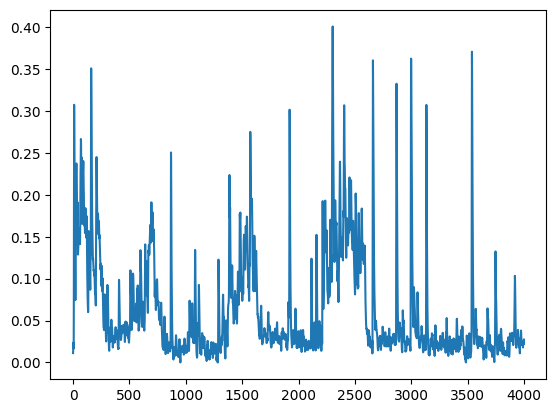

In [16]:
plt.plot(neuromod_activity[1000:5000])

In [14]:
vae, params, task_params, training_params = load_model(f'../../../models/dtt/dtt_{neuromodulation}_rank_4_231_gauss_fold_1_50ms_all_zsc')

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1


/network/iss/home/kaleab.belay/mnm/train_scripts/recordings/mPFC/../../../vi_rnn/saving.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.

In [28]:
task.n_trials, 12000 / 256

(12000, 46.875)

In [28]:
kf = KFold(n_splits=10, shuffle=False)
for fold, (train_idx, test_idx) in enumerate(kf.split(s_pt_baseline), start=1):
    if fold >1: continue 
    block_1 = train_idx[train_idx < test_idx[0]]
    block_2 = train_idx[train_idx > test_idx[-1]]
    print(f'Fold: {fold}')
    seq_periods_eval = [[test_idx[0], test_idx[-1]]]
    test_samples = spike_counts_pt_baseline[:, test_idx[0]:test_idx[-1]]
    s_test = s_pt_baseline[test_idx[0]:test_idx[-1]]

    if len(block_1) > 0 and len(block_2) > 0:
        seq_periods = [[block_1[0], block_1[-1]], [block_2[0], block_2[-1]]]
        train_samples = np.hstack([spike_counts_pt_baseline[:, block_1[0]:block_1[-1]],
                                   spike_counts_pt_baseline[:, block_2[0]:block_2[-1]]])
    elif len(block_1) > 0: 
        seq_periods = [[block_1[0], block_1[-1]]]
    else: 
        seq_periods = [[block_2[0], block_2[-1]]]
        
    print(f'Train blocks: {seq_periods}')
    print(f'Test blocks: {seq_periods_eval}')

    task_params = {
        "dur": 100,
        "n_trials": 3000,
        "name": "",
        "dataset_name": data_dir,
    }

    task = DTTDataset(task_params, 
                        spike_counts_pt_baseline.T, 
                        s_train=s_pt_baseline, 
                        s_test=s_test,
                        seq_periods=seq_periods,
                        seq_periods_eval=seq_periods_eval,
                        data_eval=test_samples.T)
  
block_start, block_end = seq_periods_eval[0]
T, dim_x = task.data_eval.shape
z_hat, _, _, _ = vae.encoder(task.data_eval[:, :].T.unsqueeze(0))
z0 = z_hat[:, :, :1].squeeze() 
Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, noise_scale=1, s=task.s_test.unsqueeze(0), sim_v=False, sim_s=True)
obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
compute_KL_divergence(obs.unsqueeze(0), task.data[block_start:block_end, :].unsqueeze(0))
# get spikes 
# lmd = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
# spikes_pred = torch.poisson(lmd).T.detach()

Fold: 1
Train blocks: [[2380, 23799]]
Test blocks: [[0, 2379]]
no input
n outliers: 1.0


nan

Text(0.5, 1.0, 'Spikes from BLA')

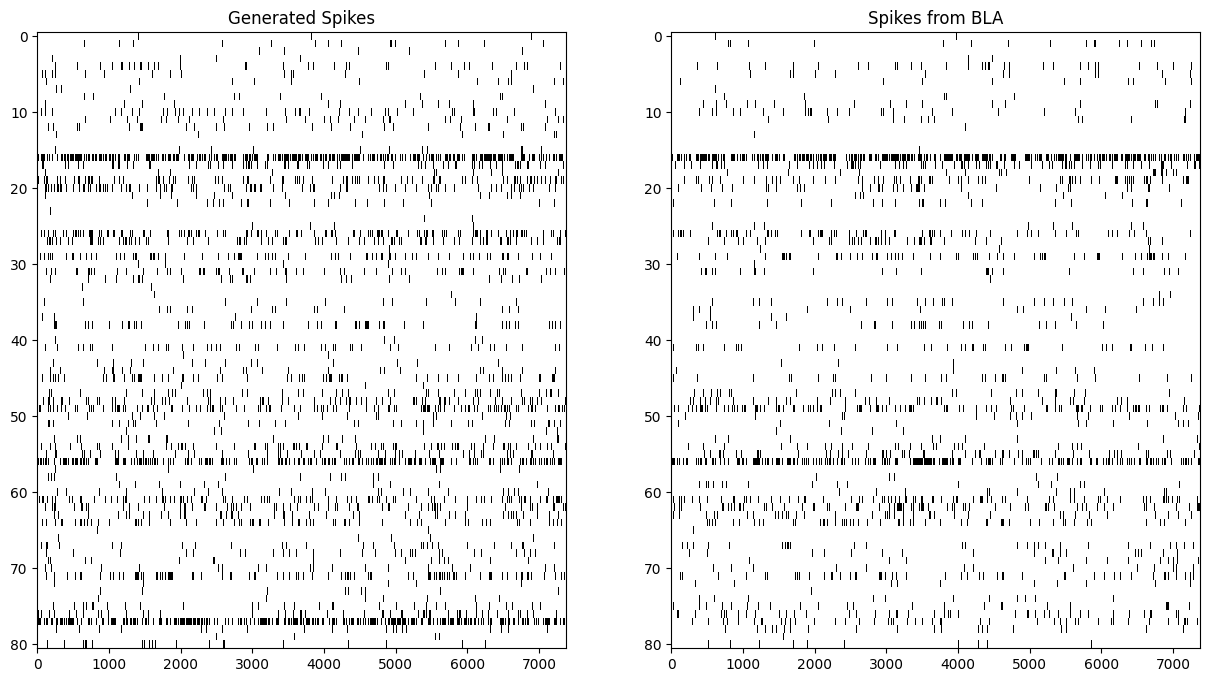

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T.cpu(), aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T.cpu(), aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

Text(0.5, 1.0, 'Spikes from BLA')

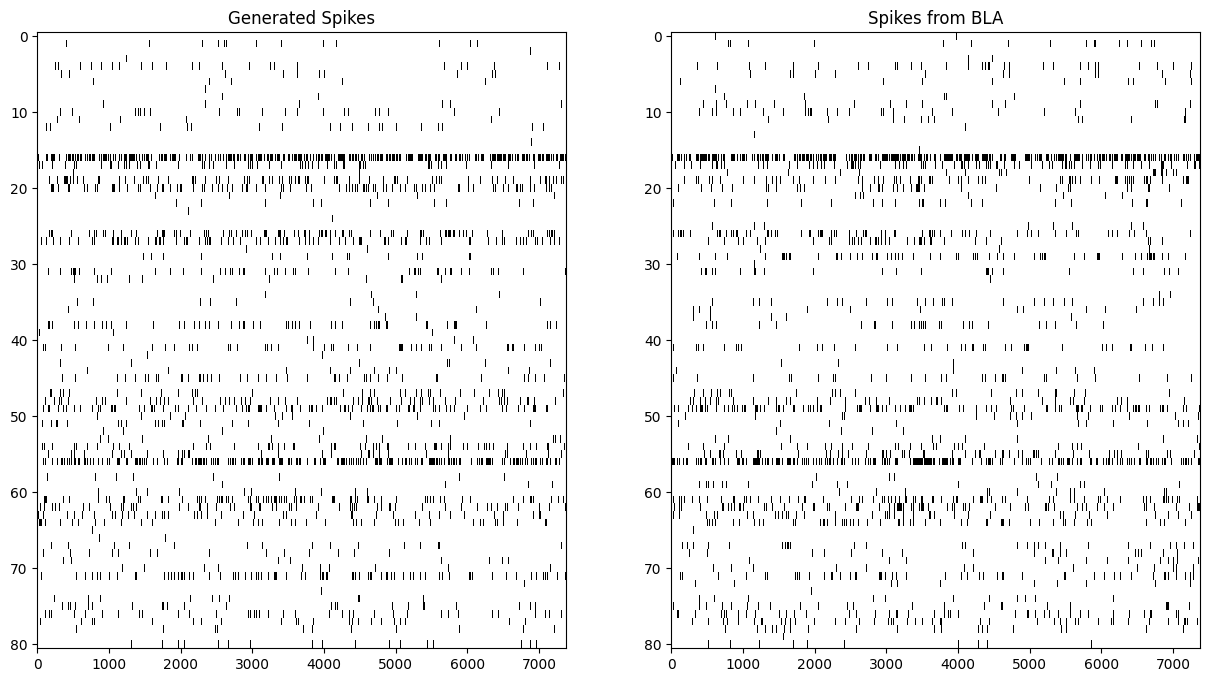

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T.cpu(), aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T.cpu(), aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

Text(0.5, 1.0, 'Spikes from BLA')

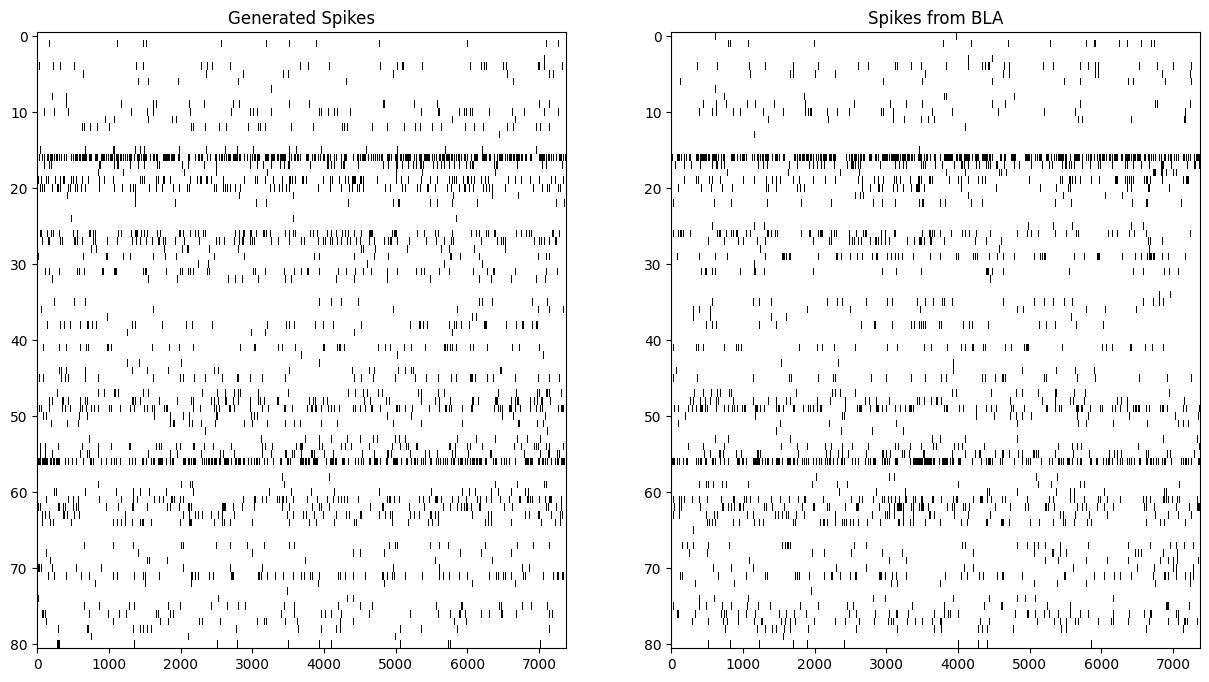

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(spikes_pred.T.cpu(), aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1].imshow(task.data_eval[:T, :].T.cpu(), aspect='auto', cmap='Greys', interpolation='none', vmax=1)

ax[0].set_title('Generated Spikes')
ax[1].set_title('Spikes from BLA')

In [15]:
CVs_isi_test, Means_isi_test, Std_isi_test = calc_isi_stats(task.data_eval[:T, :], dt=bin_size)
CVs_isi_gen, Means_isi_gen, Std_isi_gen = calc_isi_stats(spikes_pred, dt=bin_size)

Text(0.5, 1.0, 'Scatter plots of mean ISIs of test and generated samples')

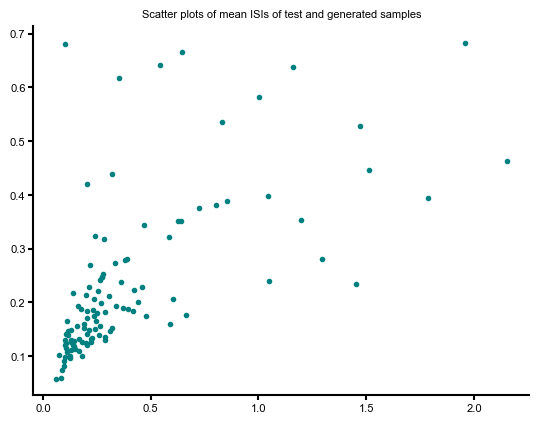

In [16]:
plt.scatter(Means_isi_gen, Means_isi_test, c='teal')
# plt.xlim([0, 4])
# plt.ylim([0, 4])
plt.title('Scatter plots of mean ISIs of test and generated samples')

Text(0.5, 1.0, 'Scatter plots of mean firing rates of test and generated samples')

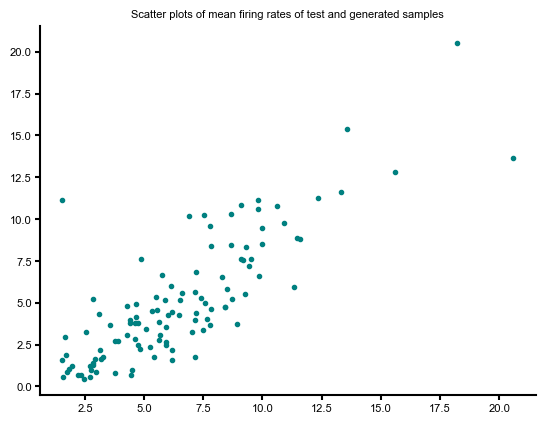

In [17]:
fr_test = torch.mean(task.data_eval[:T, :].T, axis=1) / bin_size
fr_gen = torch.mean(spikes_pred.T, axis=1) / bin_size 
plt.scatter(fr_test, fr_gen, c='teal')
# plt.xlim([0, 4])
# plt.ylim([0, 4])
plt.title('Scatter plots of mean firing rates of test and generated samples')

In [18]:
# Parameters
tau = 8  # Decay time constant

# Compute Van Rossum Distances 
vrds = np.zeros((spikes_pred.shape[1],))
for j in range(spikes_pred.shape[1]):
    vrd = van_rossum_distance(spikes_pred[:, j], task.data_eval[:, j], tau, T)
    vrds[j] = vrd 

In [22]:
np.mean(vrds), np.sum(vrds)

(21.422234754935243, 2377.868057797812)

In [20]:
np.mean(vrds), np.sum(vrds)

(21.226647551516287, 2356.157878218308)

In [18]:
np.mean(vrds), np.sum(vrds)

(21.12073954970556, 2344.4020900173173)

In [19]:
np.mean(vrds), np.sum(vrds)

(20.57248971058901, 2283.54635787538)

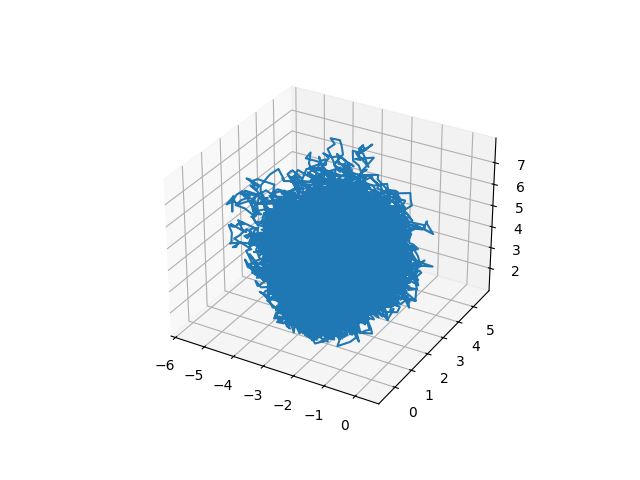

In [21]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], Z[0, 2, :, 0])

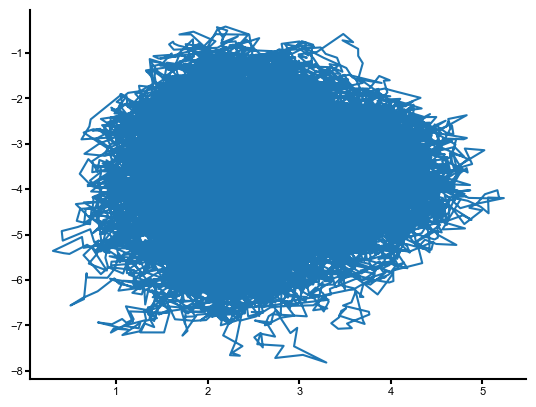

In [17]:
plt.plot(Z[0, 0, :, 0], Z[0, 1, :, 0])

In [24]:
def extract_phase_plane_vae(vae, xlims, ylims, n_points=100, h=10, inp=None, nonlinearity='relu'):
    """Extract the phase plane of the vae.rnn.
    Args:
        vae: VAE, VAE model
        xlims: float, limits for x-axis
        ylims: float, limits for y-axis
        n_points: int, number of points to sample
        h: float, step size (in ms)
    Returns:
        X: np.array (n_points x n_points), x-axis meshgrid
        Y: np.array (n_points x n_points), y-axis meshgrid
        u: np.array (n_points x n_points), x-axis velocity field
        v: np.array (n_points x n_points), y-axis velocity field
        norm: np.array (n_points x n_points), norm of the velocity field"""
    prior = vae.rnn.transition
    decay = prior.cast_A(prior.AW).detach().numpy().squeeze()
    V = (prior.n * prior.scaling).detach().numpy()
    U = prior.m_transform(prior.m).detach().numpy()
    B = prior.h.detach().numpy()
    if inp is None:
        I = np.zeros(1)
        inp = np.zeros(1)
    else:
        I = prior.Wu.detach().numpy()

    if not isinstance(xlims, list):
        xlims = [-xlims, xlims]
    if not isinstance(ylims, list):
        ylims = [-ylims, ylims]

    def dyn_eq(x, y):
        z = np.array([x, y])
        if nonlinearity == 'relu':
            zn = (decay) * z + V @ np_relu(U @ z - B + I @ inp)
        elif nonlinearity == 'clipped_relu': 
            zn = (decay) * z + V @ (np_relu(U @ z + B + I @ inp) - np_relu(U @ z + I @ inp))
            
        dz = (zn - z) / h
        return dz[0], dz[1]

    X, Y = np.meshgrid(
        np.linspace(xlims[0], xlims[1], n_points),
        np.linspace(ylims[0], ylims[1], n_points),
    )
    u, v = np.zeros_like(X), np.zeros_like(X)
    NI, NJ = X.shape

    norm = np.zeros((NI, NJ))
    for i in range(NI):
        for j in range(NJ):
            x, y = X[i, j], Y[i, j]
            dx, dy = dyn_eq(x, y)
            u[i, j] = dx
            v[i, j] = dy
            norm[i, j] = np.log(np.linalg.norm([dx, dy]))
    return X, Y, u, v, norm

In [25]:
# Extract phase planes
xlims = 15
ylims = 15
X, Y, u, v, norm = extract_phase_plane_vae(vae, xlims, ylims, n_points=2000, nonlinearity='clipped_relu')

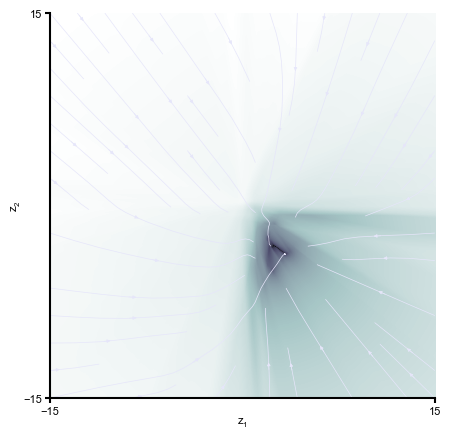

In [28]:
import matplotlib as mpl
    # Make panel A
with mpl.rc_context(fname="matplotlibrc"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    ax.imshow(
        norm,
        extent=[-xlims, xlims, -ylims, ylims],
        origin="lower",
        cmap="bone",
        vmax=np.max(norm),
        aspect="auto",
    )
    ax.streamplot(
        X, Y, u, v, color="lavender", density=0.5, linewidth=0.5, arrowsize=0.5
    )
    ax.set_box_aspect(1)
    ax.spines[["right", "top"]].set_visible(False)

    ax.set_xlim(-xlims, xlims)
    ax.set_ylim(-ylims, ylims)
    ax.set_xticks([-xlims, xlims])
    ax.set_yticks([-ylims, ylims])
    ax.set_xlabel(r"$z_1$")
    ax.set_ylabel(r"$z_2$")
    # ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], '-o', markersize=4)  

    fig.savefig('phase_portrait.svg', format='svg')




In [18]:
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic

vae_orth = orthogonalise_network(vae)

# Get all fixed points of teacher RNN
tau, pV, pU, pB, pI = get_loadings(vae_orth)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau, tau, tau, tau]), pV, pU, 0, pB
)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [15]:
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic

vae_orth = orthogonalise_network(vae)

# Get all fixed points of teacher RNN
tau, pV, pU, pB, pI = get_loadings(vae_orth)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau]), pV, pU, 0, pB
)

120
2
(240, 120)
(121, 120)
Found a fixed point
[-34.90024948]
Done, found 1 fixed points
